# Pha S — Buoc 3: Sanity check TE(ho hap->tim) vs TE(tim->ho hap)

**Day la tieu chi thoat cua Pha S.**

**Doi huong (xem docs/PHASE_S_REVIEW.md):** ket qua CHINH tren du lieu that chuyen tu ghep noi TIM-NAO (slpdb/capslpdb) sang **TIM-HO HAP (Fantasia)** - slpdb/capslpdb bi loai vi nhiem nhieu dien tim trong EEG khong khu duoc bang 5 phuong phap da thu (xem notebook 02 + PHASE_S_REVIEW.md). Fantasia SACH va ghep noi tim-ho hap (Respiratory Sinus Arrhythmia - RSA) da duoc xac lap ro trong tai lieu sinh ly hoc.

**Gia thuyet huong (ground truth tu tai lieu):** RSA la co che HO HAP dieu bien nhip tim qua phan xa phe vi - huong nhan qua CHINH da duoc chap nhan rong rai la **ho hap -> tim** (Grossman & Taylor 2007, Berntson et al. 1993). Ky vong **TE(ho hap->tim) > TE(tim->ho hap)**.

**SUA #1 (bat doi xung loc RR/RESP):** RR phai duoc loc bang-thong CUNG dai voi RESP truoc khi luu cua so (o notebook 02c) - neu khong, TE lech huong sai do bat doi xung tri nho tu tuong quan (xem PHASE_S_REVIEW.md).

**SUA #2 (chuan bi cho Q1/Q2 - gia lap so mau/pseudoreplication):** phien ban truoc gop TAT CA cua so cua TAT CA ban ghi thanh 1 tap roi bootstrap/kiem dinh tren do - **SAI ve thong ke**: cac cua so trong CUNG 1 ban ghi tuong quan voi nhau (cung 1 nguoi, cung 1 dem), khong doc lap. Coi ~4000 cua so la 4000 mau doc lap phan anh SAI do khong chac chan thuc su (day la loi 'pseudoreplication' kinh dien, reviewer thong ke/sinh ly hoc se bat ngay). Notebook nay gio dung **2 lop phan tich**: (A) SO BO tren cua so gop - CHI de tham khao truc quan, KHONG dung lam ket luan; (B) **CHINH THUC theo don vi ban ghi** (`run_sanity_check_per_record`) - moi ban ghi 1 gia tri TE trung binh, kiem dinh tren N=so_ban_ghi (don vi mau DUNG, phan anh dung do khong chac chan).

Notebook nay TU NAP cua so da luu boi notebook 02c, GOM theo TUNG ban ghi (khong gop lien ngay) de co the lam ca 2 lop phan tich tren.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import os
os.environ.setdefault('JAVA_HOME', r'C:\Program Files\Java\jdk-22')
import yaml, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path

from pqrst.data.synthetic.corpus import load_corpus
from pqrst.evaluation.sanity_check import (
    bidirectional_te, bidirectional_te_per_record,
    run_sanity_check, run_sanity_check_per_record,
)
from pqrst.estimators.mine.amortized import AmortizedTEEstimator
from pqrst.baselines.ksg import KSGTEEstimator

BASE = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
cfg = yaml.safe_load(open(BASE/'configs'/'real'/'preprocessing.yaml', encoding='utf-8'))

# LUU Y: dung checkpoint DA CHUAN HOA tu notebook 00, KHONG phai ban goc phi_amortized.pt!
est_amortized = AmortizedTEEstimator.load(
    str(BASE/'results'/'checkpoints'/'phi_amortized_standardized.pt'))

## 1. Nap cua so, GOM THEO TUNG BAN GHI (khong gop lien ngay)

Chi dung cac ban ghi da PASS o notebook 02c (`quality_report.csv`, `verdict=='PASS'`). `records[record_id] = (windows_resp_to_rr, windows_rr_to_resp)`.

In [2]:
proc_dir = BASE / 'data' / 'processed' / 'fantasia'
quality = pd.read_csv(proc_dir / 'quality_report.csv')
passed_records = quality.loc[quality['verdict'] == 'PASS', 'record_id'].tolist()
print(f'{len(passed_records)}/{len(quality)} ban ghi PASS, dung cho sanity check:')
print(passed_records)

records = {}  # record_id -> (windows_resp_to_rr, windows_rr_to_resp)
for rid in passed_records:
    w_rr_to_resp = load_corpus(str(proc_dir / (rid + '_fwd.npz')))
    w_resp_to_rr = load_corpus(str(proc_dir / (rid + '_bwd.npz')))
    records[rid] = (w_resp_to_rr, w_rr_to_resp)

n_windows_total = sum(len(v[0]) for v in records.values())
print(f'Tong so ban ghi: {len(records)}, tong cua so (mot chieu): {n_windows_total}')

17/40 ban ghi PASS, dung cho sanity check:
['f1o09', 'f1y01', 'f1y02', 'f1y04', 'f1y05', 'f1y06', 'f1y07', 'f1y08', 'f1y09', 'f1y10', 'f2o06', 'f2o07', 'f2y01', 'f2y06', 'f2y07', 'f2y08', 'f2y09']
Tong so ban ghi: 17, tong cua so (mot chieu): 4049


## 2. (SO BO - khong dung lam ket luan) TE gop cua so, ca 2 estimator

**CHI de tham khao truc quan** - don vi mau la cua so, VI PHAM gia dinh doc lap (xem canh bao muc dau notebook). Ket luan CHINH THUC nam o Muc 3.

In [3]:
all_resp_to_rr = [w for rid in records for w in records[rid][0]]
all_rr_to_resp = [w for rid in records for w in records[rid][1]]

for name, est in [('Amortized', est_amortized), ('KSG', KSGTEEstimator())]:
    res = bidirectional_te(all_resp_to_rr, all_rr_to_resp, est)
    print(f"[SO BO - gop cua so] {name}: TE(resp->tim)={res['te_forward_mean']:.4f}  "
          f"TE(tim->resp)={res['te_backward_mean']:.4f}  hieu={res['difference']:.4f}")

[SO BO - gop cua so] Amortized: TE(resp->tim)=-0.2474  TE(tim->resp)=-0.0705  hieu=-0.1769
[SO BO - gop cua so] KSG: TE(resp->tim)=0.1110  TE(tim->resp)=0.0929  hieu=0.0181


## 3. ✅ KIEM DINH CHINH THUC — theo DON VI BAN GHI (khong pseudoreplication)

Moi ban ghi -> 1 gia tri TE trung binh MOI CHIEU (`bidirectional_te_per_record`). Kiem dinh tren N=so_ban_ghi (`run_sanity_check_per_record`): bootstrap CI cua hieu so + kiem dinh Wilcoxon signed-rank (phi tham so, phu hop N nho) nhu 1 kiem dinh doc lap thu 2. **Day la ket luan PASS/FAIL chinh thuc cua Pha S.**

In [4]:
final_results = {}
per_record_te = {}
for name, est in [('Amortized', est_amortized), ('KSG', KSGTEEstimator())]:
    per_rec = bidirectional_te_per_record(records, est)
    per_record_te[name] = per_rec
    fwd = [v['te_forward'] for v in per_rec.values()]
    bwd = [v['te_backward'] for v in per_rec.values()]
    res = run_sanity_check_per_record(fwd, bwd, n_bootstrap=cfg['n_bootstrap'], seed=cfg['seed'])
    final_results[name] = res
    print(f"--- {name} (N={res['n_records']} ban ghi) ---")
    print(f"  TE(resp->tim)={res['te_forward_mean']:.4f}, TE(tim->resp)={res['te_backward_mean']:.4f}")
    print(f"  CI hieu 95% (theo ban ghi): [{res['ci_difference'][0]:.4f}, {res['ci_difference'][1]:.4f}]")
    print(f"  Wilcoxon signed-rank p={res['wilcoxon_p']:.4f}")
    print(f"  PASSED: {res['passed']}")

Sanity check (theo ban ghi, N=17) FAILED.
--- Amortized (N=17 ban ghi) ---
  TE(resp->tim)=-0.2474, TE(tim->resp)=-0.0704
  CI hieu 95% (theo ban ghi): [-0.2119, -0.1434]
  Wilcoxon signed-rank p=1.0000
  PASSED: False
Sanity check (theo ban ghi, N=17) PASSED: TE forward > TE backward ro ret, CI hieu so khong chua 0, Wilcoxon p=0.0116.
--- KSG (N=17 ban ghi) ---
  TE(resp->tim)=0.1109, TE(tim->resp)=0.0929
  CI hieu 95% (theo ban ghi): [0.0039, 0.0353]
  Wilcoxon signed-rank p=0.0116
  PASSED: True


## 4. Hinh: (a) so sanh gop vs theo ban ghi, (b) bieu do bat cap (paired) tung ban ghi

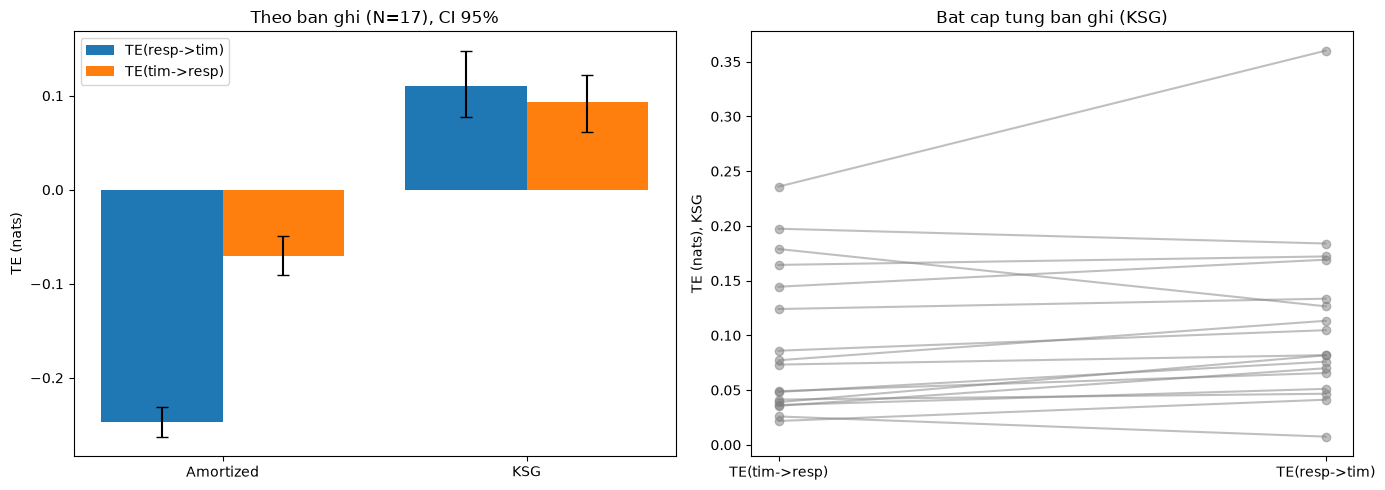

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

names = list(final_results.keys())
x = np.arange(len(names))
fwd_means = [final_results[n]['te_forward_mean'] for n in names]
bwd_means = [final_results[n]['te_backward_mean'] for n in names]
fwd_err = [[final_results[n]['te_forward_mean']-final_results[n]['ci_forward'][0],
            final_results[n]['ci_forward'][1]-final_results[n]['te_forward_mean']] for n in names]
bwd_err = [[final_results[n]['te_backward_mean']-final_results[n]['ci_backward'][0],
            final_results[n]['ci_backward'][1]-final_results[n]['te_backward_mean']] for n in names]
axes[0].bar(x-0.2, fwd_means, 0.4, yerr=np.array(fwd_err).T, label='TE(resp->heart)', capsize=4)
axes[0].bar(x+0.2, bwd_means, 0.4, yerr=np.array(bwd_err).T, label='TE(heart->resp)', capsize=4)
axes[0].set_xticks(x); axes[0].set_xticklabels(names); axes[0].legend()
axes[0].set_ylabel('TE (nats)'); axes[0].set_title(f'Per-record (N={final_results["KSG"]["n_records"]}), 95% CI')

rec_ids = list(records.keys())
ksg_fwd = [per_record_te['KSG'][r]['te_forward'] for r in rec_ids]
ksg_bwd = [per_record_te['KSG'][r]['te_backward'] for r in rec_ids]
for i in range(len(rec_ids)):
    axes[1].plot([0, 1], [ksg_bwd[i], ksg_fwd[i]], '-o', color='gray', alpha=0.5)
axes[1].set_xticks([0, 1]); axes[1].set_xticklabels(['TE(heart->resp)', 'TE(resp->heart)'])
axes[1].set_ylabel('TE (nats), KSG'); axes[1].set_title('Per-record TE asymmetry (KSG)')

plt.tight_layout()
out_dir = BASE/'results'/'figures'; out_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(out_dir/'phase_s_bidirectional_te.png', dpi=100)
plt.show()

## 5. KET LUAN SANITY CHECK (chinh thuc, theo ban ghi)

Neu **khong dat**, kiem tra theo dung thu tu (`docs/PHASE_S_GUIDE.md` muc 3.4):
1. Dong bo hoa  2. Ectopic  3. Do dai cua so  4. Doi chieu KSG

Va neu sau tat ca van khong dat: bao cao trung thuc. Xem `docs/PHASE_S_REPORT.md` ve ly do Amortized FAIL tren du lieu that (dieu tra rieng, khong phai bug).

In [6]:
for name, res in final_results.items():
    verdict = 'PASS' if res['passed'] else 'FAIL'
    print(f"[{verdict}] {name} (N={res['n_records']} ban ghi): TE(resp->tim) "
          f"{'>' if res['te_forward_mean']>res['te_backward_mean'] else '<='} TE(tim->resp), "
          f"CI hieu khong chua 0: {res['ci_difference'][0] > 0}, Wilcoxon p={res['wilcoxon_p']:.4f}")

overall_pass = any(r['passed'] for r in final_results.values())
print()
print('=== KET LUAN CHUNG (theo don vi ban ghi - dung thong ke): ' + ('DAT' if overall_pass else 'CHUA DAT') + ' ===')

[FAIL] Amortized (N=17 ban ghi): TE(resp->tim) <= TE(tim->resp), CI hieu khong chua 0: False, Wilcoxon p=1.0000
[PASS] KSG (N=17 ban ghi): TE(resp->tim) > TE(tim->resp), CI hieu khong chua 0: True, Wilcoxon p=0.0116

=== KET LUAN CHUNG (theo don vi ban ghi - dung thong ke): DAT ===
